In [8]:
#IMPORT LIBRARIES and packages
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import openpyxl
import sys
import copy
import math
%matplotlib inline

# LOAD DATASET - provided by task 2 team leader Sulaiman Mutawalli
data_df = pd.read_excel(r'/Users/dorsa/data/linear.xlsx')

In [61]:
data_df.head()

,year,population,gdp,steel,coal,oil,gas,co2
0,1950,2.499322,0.89,189.0,11332.575,6055.578,2136.6338,6.003272
1,1951,2.543130,0.94,205.0,11939.019,6867.236,2534.5093,6.379796
2,1952,2.590271,0.99,221.0,11870.501,7218.299,2729.6267,6.465727
3,1953,2.640279,1.04,237.0,11923.186,7632.513,2886.3450,6.647763
4,1954,2.691979,1.09,253.0,11769.438,7990.694,3027.5981,6.789969


In [9]:
x = data_df.drop(['co2'], axis=1).values
y = data_df['co2'].values

In [10]:
# SPLIT THE DATASET IN TRAINING SET AND TEST SET
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state=0)

In [11]:
# TRAIN THE MODEL ON THE TRAINING SET
from sklearn.linear_model import LinearRegression
ml=LinearRegression()
ml.fit(x_train,y_train)

LinearRegression()

In [12]:
# PREDICT THE TEST SET RESULTS
y_pred = ml.predict(x_test)
print(y_pred)

[17.98506099 18.59045395 24.89199329 15.84721705 19.28584965 26.00776802
  8.15706854 31.8864115  19.74669663 36.41829995 30.87484846 18.86651105
 19.04312926 22.84230889 19.14031778 29.99888362 35.82539008 34.93079541
 22.70869313  6.730157   36.02138042 25.47649454]


In [13]:
ml.predict([[1950,2.499322,0.89,189.0,11332.575,6055.578,2136.6338]])

array([6.05974013])

In [14]:
# EVALUATE THE MODEL
r2_score(y_test,y_pred)

0.9984473779209648

Text(0.5, 1.0, 'Actual CO2 Emissions vs Predicted CO2 Emissions')

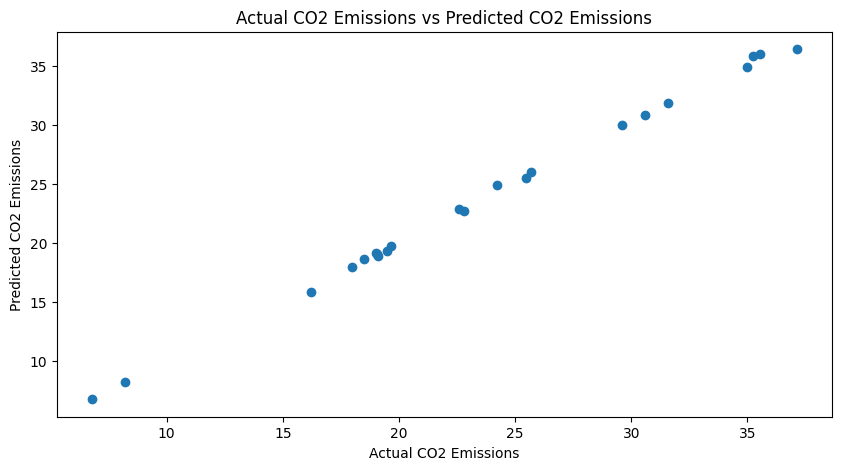

In [21]:
# PLOT THE RESULTS
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual CO2 Emissions')
plt. ylabel('Predicted CO2 Emissions')
plt.title('Actual CO2 Emissions vs Predicted CO2 Emissions')

In [23]:
# PREDICTED VALLUES

pred_y_df = pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred})
pred_y_df[0:20]

,Actual Value,Predicted Value,Difference
0,17.991887,17.985061,0.006826
1,18.502846,18.590454,-0.087608
2,24.213260,24.891993,-0.678733
3,16.228729,15.847217,0.381512
4,19.501264,19.285850,0.215414
5,25.668049,26.007768,-0.339719
6,8.185547,8.157069,0.028478
7,31.564031,31.886411,-0.322380
8,19.664754,19.746697,-0.081943
9,37.123852,36.418300,0.705552
